# Task 6

# Objective : Group customers based on behaviour

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Select Features

In [4]:
x = df[['Annual Income (k$)','Spending Score (1-100)']]

## Scale Data

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

## Elbow Mathod

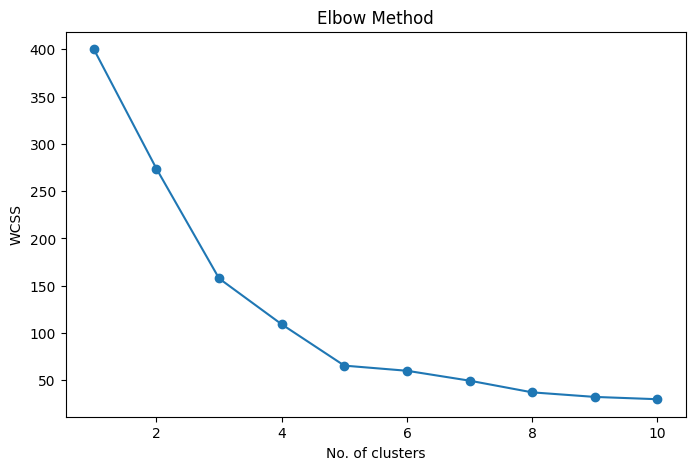

In [6]:
wcss = []

for i in range(1,11):
  kmeans = KMeans(
      n_clusters=i,
      random_state=42
  )

  kmeans.fit(X_scaled)

  wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.title("Elbow Method")
plt.xlabel("No. of clusters")
plt.ylabel("WCSS")

plt.show()

## Apply K-Means

In [7]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1    Male   19                  15                      39        4
1           2    Male   21                  15                      81        2
2           3  Female   20                  16                       6        4
3           4  Female   23                  16                      77        2
4           5  Female   31                  17                      40        4


## Visualize Customer Clusters

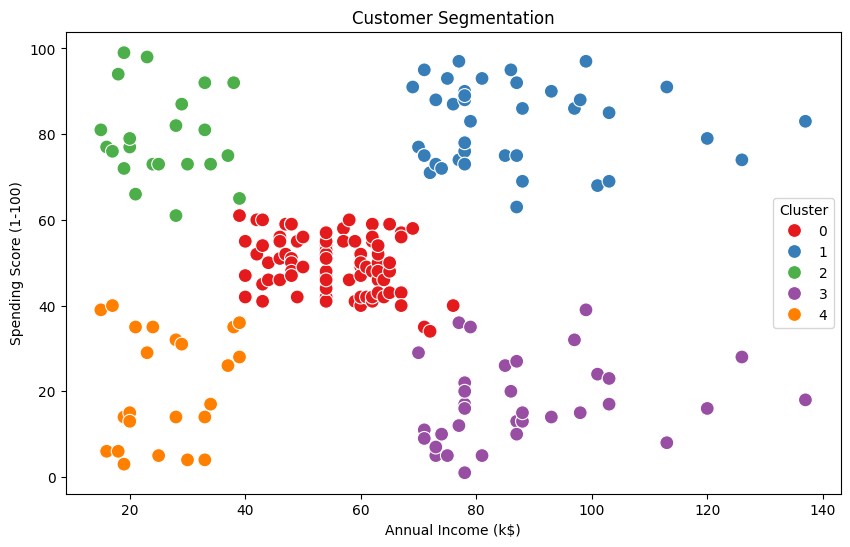

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation')

plt.show()

## Cluster Summary

In [9]:
cluster_summary = df.groupby('Cluster')[
    ['Annual Income (k$)',
     'Spending Score (1-100)']
].mean()

print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


## Visualize Cluster Size

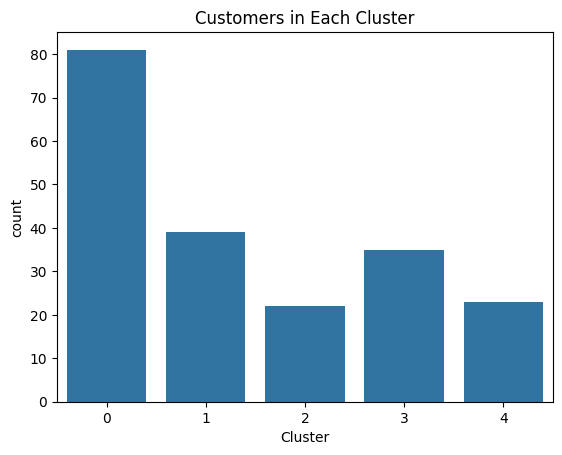

In [10]:
sns.countplot(
  x='Cluster',
  data=df
)

plt.title('Customers in Each Cluster')

plt.show()